# Atividade 1 – Segmentação
**Alunos:**
- Henryque Oliveira Affiune (202201634)
- Matheus Sousa Marinho (202206132)
- Rodrigo de Oliveira Ribeiro (201811631)


Seções do notebook:
- Parte I: Limiarização (manual, Otsu, adaptativa)
- Parte II: Espaços de cor (RGB, HSV, L*a*b*)
- Parte III: Agrupamento k-means no plano a*b*
- Parte IV: Morfologia e refino das máscaras
- Análise comparativa final


In [11]:
from pathlib import Path
import sys

import numpy as np
import cv2
from skimage import color
import matplotlib.pyplot as plt
import cv2

sys.path.append("../src")
from otsu import otsu_threshold

plt.rcParams["figure.figsize"] = (6, 4)

# Raiz do projeto = pai da pasta notebook/
ROOT = Path().resolve().parent
DATA_DIR = ROOT / "images" / "input"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "images" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Carregamento de imagem

Aqui ficam funções auxiliares para leitura e exibição das imagens da pasta `images/input`.


In [3]:
# carregamento da imagem RGB da pasta images/input
def load_rgb(name: str):
    """Carrega uma imagem RGB da pasta `images/input`."""
    path = DATA_DIR / name
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

# show imagens lado a lado
def show_side_by_side(images, titles):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


## Parte I: Limiarização Manual

Ponto de partida da segmentação: converter a imagem para escala de cinza e aplicar um limiar fixo T escolhido manualmente. O objetivo é entender o mecanismo básico e observar suas limitações antes de avançar para métodos automáticos.

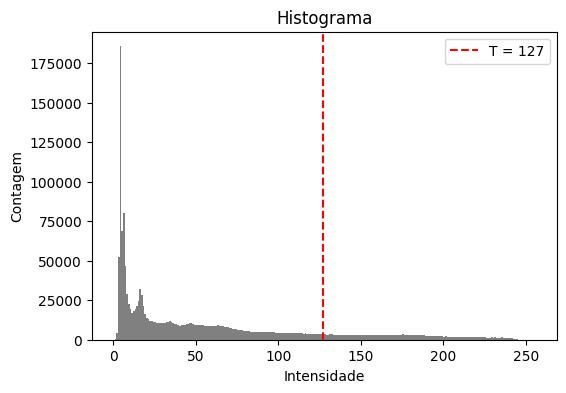

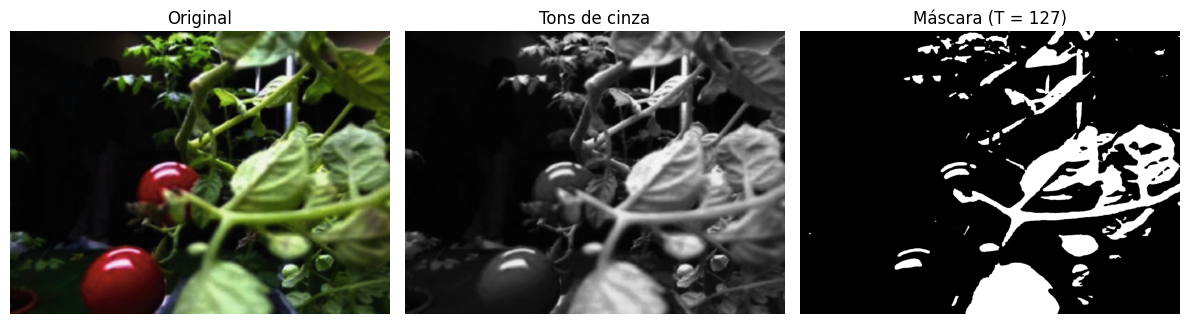

In [4]:
# Carrega a imagem colorida e converte para escala de cinza
img_rgb = load_rgb("tomates-corke.png")
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Limiar fixo escolhido manualmente — pixels >= T viram branco, demais preto
T = 127
mask = (img_gray >= T).astype(np.uint8) * 255

# Histograma da imagem em cinza com marcação visual do limiar escolhido
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(T, color='red', linestyle='--', label=f'T = {T}')
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

# Comparação visual: original, cinza e máscara binária
show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (T = {T})"]
)

## Limiarização Método Otsu

Este bloco demonstra como chamar a função `otsu_threshold` implementada em `src/otsu.py`.


Limiar de Otsu: 90


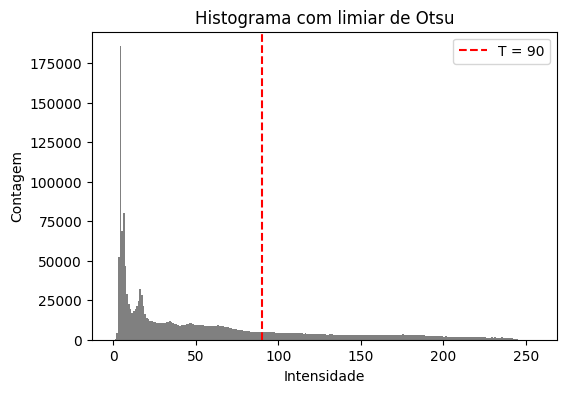

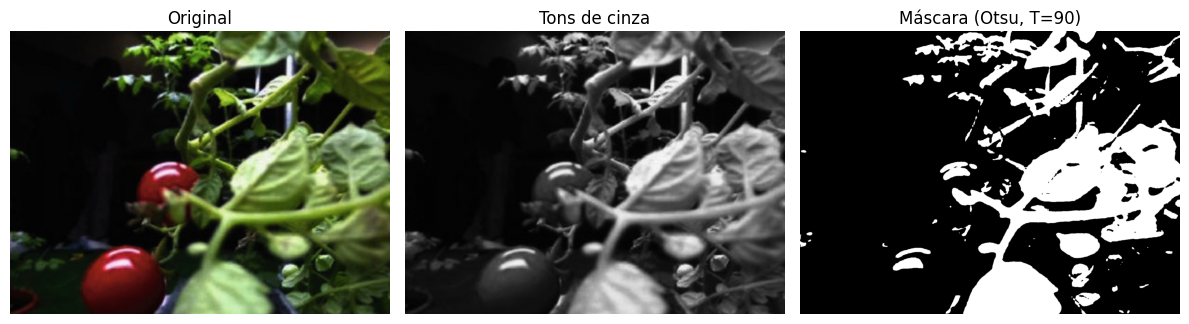

In [5]:
img_rgb = load_rgb("tomates-corke.png")  # ajuste o nome do arquivo se necessário
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

t = otsu_threshold(img_gray)
print("Limiar de Otsu:", t)

mask = (img_gray >= t).astype(np.uint8) * 255


# Histograma com o limiar de Otsu marcado
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(t, color='red', linestyle='--', label=f'T = {t}')
plt.title("Histograma com limiar de Otsu")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (Otsu, T={t})"]
)

## Limiarização Adaptativa

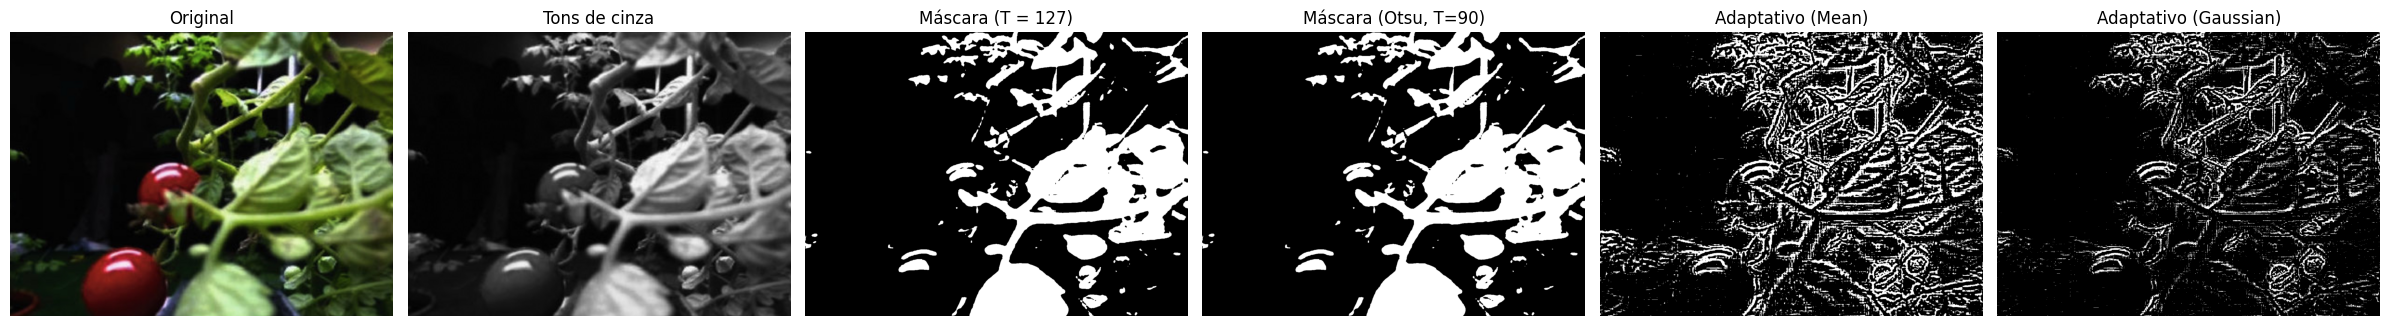

In [6]:
img_rgb = load_rgb("tomates-corke.png")  # ajuste o nome do arquivo se necessário
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

#cv2.adaptiveThreshold(img_gray, maxValue, adaptiveMethod, thresholdType, blockSize, C)
mask_mean = cv2.adaptiveThreshold( img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 11, 2)
mask_gaussian = cv2.adaptiveThreshold( img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

show_side_by_side(
    [img_rgb, img_gray, mask, mask, mask_mean, mask_gaussian],
    ["Original", "Tons de cinza",f"Máscara (T = {T})", f"Máscara (Otsu, T={t})", "Adaptativo (Mean)", "Adaptativo (Gaussian)"]
)

## Parte III: Agrupamento k-means no plano a\*b\*

Implementação manual do k-means sobre os canais cromáticos a\* e b\* do espaço L\*a\*b\*.
O objetivo é agrupar pixels por similaridade de cor, descartando a luminância (canal L\*).

In [12]:
from kmeans import kmeans_ab

img_rgb = load_rgb("tomates-corke.png")

# Executa o k-means no plano a*b* para diferentes valores de k.
# Para cada k, armazena: rótulos por pixel, centróides finais e
# histórico de snapshots (início, meio, convergência).
results = {}
for k in [2, 3, 4, 5]:
    labels, centroids, history = kmeans_ab(img_rgb, k=k)
    results[k] = (labels, centroids, history)
    print(f"k={k}  →  {len(history)} snapshots, "
        f"convergiu na iteração {history[-1][0]}")

k=2  →  3 snapshots, convergiu na iteração 7
k=3  →  3 snapshots, convergiu na iteração 18
k=4  →  3 snapshots, convergiu na iteração 10
k=5  →  3 snapshots, convergiu na iteração 41


## Evolução dos centróides ao longo das iterações do k-means.
Aqui, para cada valor de k, plota os centróides em 3 momentos (início, meio, momento de convergência).

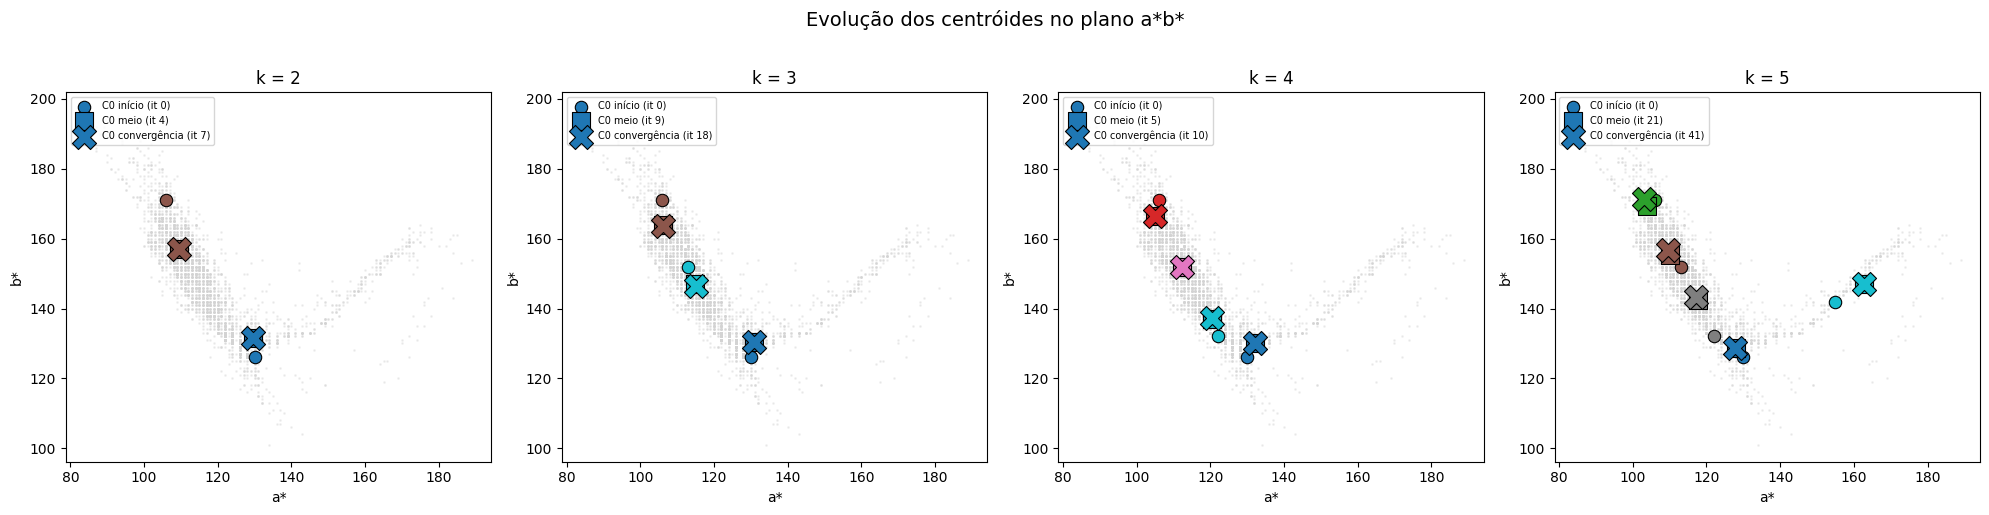

In [8]:
# Evolução dos centróides ao longo das iterações do k-means.
# Para cada k, plota os centróides em 3 momentos (início, meio, convergência)
# sobre uma nuvem cinza de ~5000 pixels amostrados no plano a*b*.
# Marcadores maiores = iterações mais avançadas.

moment_labels = ["início", "meio", "convergência"]
marker_sizes = [80, 160, 300]       # tamanho cresce com a iteração
markers = ["o", "s", "X"]           # forma muda para distinguir momentos

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (k, (labels, centroids, history)) in zip(axes, results.items()):
    # Converte a imagem para L*a*b* e extrai os canais cromáticos a*, b*
    lab_full = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float64)
    ab = lab_full[:, :, 1:3].reshape(-1, 2)

    # Amostra aleatória de pixels como fundo cinza claro
    idx = np.random.RandomState(0).choice(ab.shape[0], size=min(5000, ab.shape[0]), replace=False)
    ax.scatter(ab[idx, 0], ab[idx, 1], c="lightgray", s=1, alpha=0.3)

    colors = plt.cm.tab10(np.linspace(0, 1, max(k, 3)))[:k]

    # Sobrepõe os centróides de cada snapshot (início → meio → fim)
    for snap_idx, (it_num, _, ctrs) in enumerate(history):
        for j in range(k):
            ax.scatter(
                ctrs[j, 0], ctrs[j, 1],
                color=colors[j],
                s=marker_sizes[snap_idx],
                marker=markers[snap_idx],
                edgecolors="black",
                linewidths=0.8,
                label=f"C{j} {moment_labels[snap_idx]} (it {it_num})" if j == 0 else None,
                zorder=5,
            )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("a*")
    ax.set_ylabel("b*")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Evolução dos centróides no plano a*b*", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "kmeans_centroid_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfico de dispersão (scatter) dos pixels no plano a*b*.
Cada pixel amostrado é colorido pela cor do cluster ao qual foi atribuído, permitindo visualizar como o k-means particionou o espaço cromático. Os centroides finais são marcados com "X".


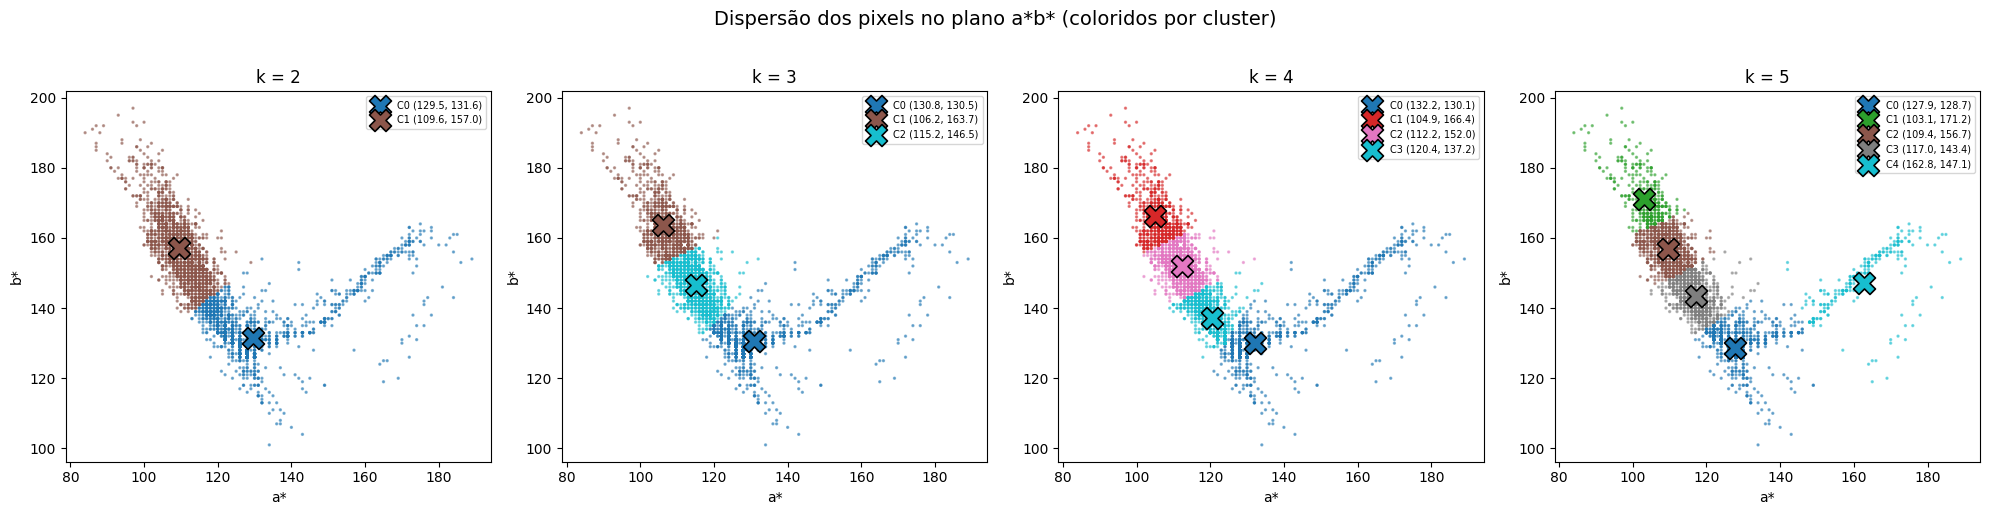

In [ ]:
n_sample = 5000
rng = np.random.RandomState(0)

# Extrai os canais a* e b* de toda a imagem
lab_full = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float64)
ab_all = lab_full[:, :, 1:3].reshape(-1, 2)

# Seleciona ~5000 pixels aleatórios para não sobrecarregar o gráfico
idx_sample = rng.choice(ab_all.shape[0], size=min(n_sample, ab_all.shape[0]), replace=False)

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (k, (labels, centroids, _)) in zip(axes, results.items()):
    labels_flat = labels.ravel()

    # Mapeia cada cluster para uma cor distinta (tab10)
    cluster_colors = plt.cm.tab10(np.linspace(0, 1, max(k, 3)))[:k]
    pixel_colors = cluster_colors[labels_flat[idx_sample]]

    # Plota os pixels amostrados, coloridos pelo cluster
    ax.scatter(
        ab_all[idx_sample, 0], ab_all[idx_sample, 1],
        c=pixel_colors, s=2, alpha=0.5,
    )

    # Sobrepõe os centróides finais com coordenadas na legenda
    for j in range(k):
        ax.scatter(
            centroids[j, 0], centroids[j, 1],
            color=cluster_colors[j], s=250, marker="X",
            edgecolors="black", linewidths=1.2, zorder=10,
            label=f"C{j} ({centroids[j,0]:.1f}, {centroids[j,1]:.1f})",
        )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("a*")
    ax.set_ylabel("b*")
    ax.legend(fontsize=7, loc="best")

fig.suptitle("Dispersão dos pixels no plano a*b* (coloridos por cluster)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "kmeans_scatter_ab.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparação das máscaras segmentadas para cada valor de k.
A coloração dos pixels é baseada na cor média do seu cluster, produzindo uma "posterização" que revela as regiões identificadas.


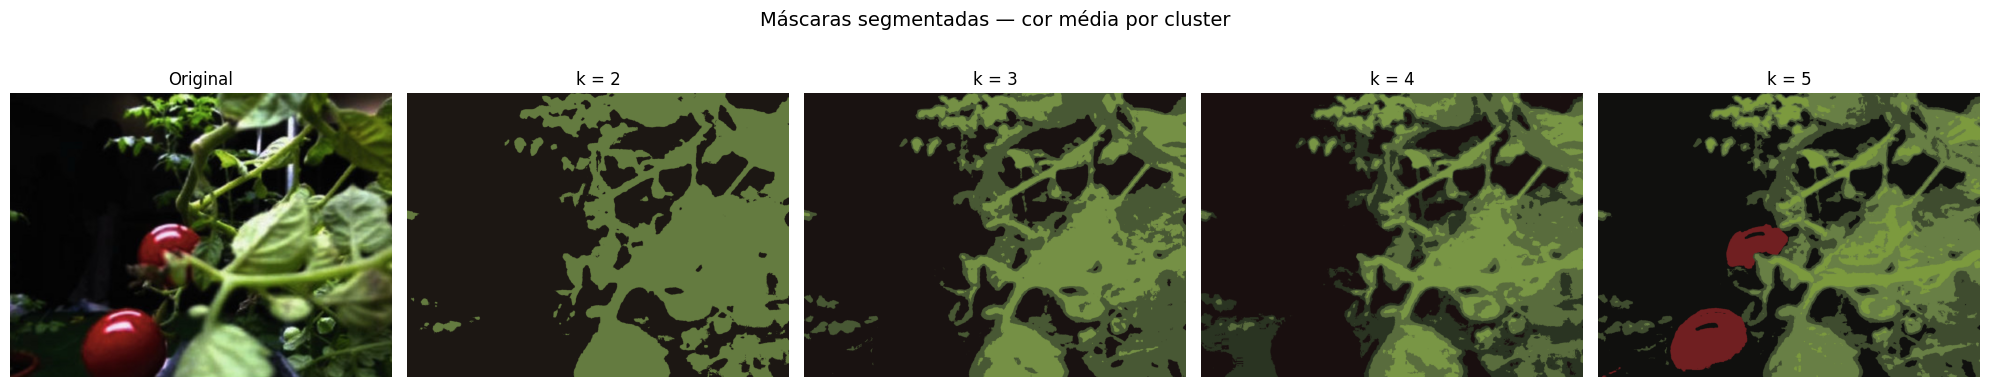

In [ ]:
def recolor_by_mean(img_rgb, labels, k):
    """Recolore cada cluster com a cor RGB média dos pixels que lhe pertencem."""
    out = np.zeros_like(img_rgb)
    for j in range(k):
        mask = labels == j
        if mask.any():
            # Calcula a cor média dos pixels pertencentes ao cluster j
            mean_color = img_rgb[mask].mean(axis=0).astype(np.uint8)
            out[mask] = mean_color
    return out

# Monta a fileira: imagem original + uma máscara por valor de k
images_row = [img_rgb]
titles_row = ["Original"]

for k, (labels, centroids, _) in results.items():
    seg = recolor_by_mean(img_rgb, labels, k)
    images_row.append(seg)
    titles_row.append(f"k = {k}")

# Exibe tudo lado a lado para facilitar a comparação
fig, axes = plt.subplots(1, len(images_row), figsize=(4 * len(images_row), 4))
for ax, img, title in zip(axes, images_row, titles_row):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle("Máscaras segmentadas — cor média por cluster", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "kmeans_masks_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Reflexão — Parte III

1. Clusters definidos apenas por cromaticidade conseguem separar "tomate" de "folha" sem depender da luminância?
> Depende da imagem e sua cromaticidade. De fato, separar somente por a* b* é possível se o tomate e a folha ocuparem regiões distintas no plano a* b*.
<br>
2. Em que casos excluir o canal L\* é vantajoso, e em quais isso provoca perda de informação relevante?
> Excluir o canal L\* é vantajoso quando a luminância não é relevante para a segmentação. Por exemplo, em imagens de cor predominante, como folhas verdes, o canal L\* pode ser excluído sem perda de informação.
<br>
3. Como o valor de k afeta a qualidade da segmentação? Qual k pareceu mais adequado para esta imagem?
> O valor de k acaba afetando diretamente a qualidade de segmentação. O valor de k define a quantidade de clusters formados no início do processo de segmentação. Quanto maior o número de k, mais clusters são formados e mais segmentações são possíveis. Porém dependendo da imagem, não é necessário utilizar um valor muito alto de k para obter uma boa segmentação.

